# Three-station continuous-audio tracking pilot

**TL;DR.** The corrected integration pilot uses one pooled calibration per `(station, estimator)` and does not select uncertainty from evaluator trajectory/SNR labels. The 4.5 s records place the fixed source-time manoeuvre in `[2.5, 3.5) s`: 10/12 method-sequences confirm before the manoeuvre and receive corrections during it. Both acceleration/−6 dB streams remain explicit initialization failures. The known 10 kHz emitted band is checked by the Doppler/Nyquist guard. This is a small offline synthetic pilot, not real-time or field qualification.

## Frozen protocol and interpretation

The protocol is stored in `THREE_STATION_AUDIO_PROTOCOL.md`: three tetrahedral stations, 48 kHz, 1024/512 frames, 4.5 s records, random broadband source, SNR −6/10 dB, CV/acceleration/smooth-turn trajectories, and disjoint calibration/evaluation seeds. GCC and SRP process every frame. The tracker receives deterministic frame indices `0,32,64,...` for computational feasibility. Calibration pools all six calibration scenarios into one fixed bias/R per station and estimator; trajectory and SNR labels are evaluator-only at lookup time. Overlapping frames are dependent, and rare tails are not qualified.

In [1]:
from pathlib import Path
import csv, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'

def load_csv(name):
    with (RESULTS / name).open(encoding='utf-8', newline='') as stream:
        return list(csv.DictReader(stream))

calibration = load_csv('three_station_audio_calibration.csv')
bearings = load_csv('three_station_audio_bearing_results.csv')
tracking = load_csv('three_station_audio_tracking_results.csv')
updates = load_csv('three_station_audio_update_results.csv')
phases = load_csv('three_station_audio_phase_summary.csv')
sequences = load_csv('three_station_audio_sequence_results.csv')
summary = load_csv('three_station_audio_summary.csv')
seed_rows = load_csv('three_station_audio_seed_provenance.csv')
len(calibration), len(bearings), len(tracking), len(updates), len(phases), len(sequences), len(summary), len(seed_rows)

(6, 15120, 504, 316, 36, 12, 12, 12)

In [2]:
assert (len(calibration), len(bearings), len(tracking), len(updates), len(phases), len(sequences), len(summary), len(seed_rows)) == (6, 15120, 504, 316, 36, 12, 12, 12)
assert {(row['station_id'], row['estimator_variant']) for row in calibration} == {
    (f'S{i}', method) for i in range(3)
    for method in ('all_6_equal_gcc_wls', 'equal_weight_srp_phat')
}
assert all(int(row['physical_configuration_count']) == 6 for row in calibration)
assert all(int(row['independent_sequence_count']) == 6 for row in calibration)
assert all(row['truth_used_by_audio_estimator'] == 'False' for row in bearings)
assert all(row['truth_used_by_tracker'] == 'False' for row in tracking + updates)
assert all(row['doppler_bandlimit_checked'] == 'True' for row in bearings)
assert {float(row['source_maximum_frequency_hz']) for row in bearings} == {10000.0}
assert all(float(row['true_emission_time_s_evaluator_only']) < float(row['frame_center_reception_time_s']) < float(row['frame_end_reception_time_s']) < float(row['available_timestamp_s']) for row in bearings)
assert sum(int(row['accepted_update_count']) for row in sequences) == sum(row['update_applied'] == 'True' for row in updates) == 286
assert sum(int(row['rejected_update_count']) for row in sequences) == sum(row['update_applied'] == 'False' for row in updates) == 30
assert sum(row['confirmed_before_manoeuvre'] == 'True' for row in sequences) == 10
assert sum(row['final_valid'] == 'True' for row in sequences) == 10
assert all(int(row['accepted_update_count']) == 9 for row in phases if row['motion_phase'] == 'during_manoeuvre' and row['confirmed_before_manoeuvre'] == 'True')

sequence_seeds = {split: {int(row['sequence_seed']) for row in seed_rows if row['split'] == split} for split in ('calibration', 'evaluation')}
role_seeds = {split: set() for split in sequence_seeds}
for row in seed_rows:
    values = [int(row['source_seed']), *map(int, json.loads(row['noise_seeds_json']))]
    assert len(values) == len(set(values))
    assert not role_seeds[row['split']].intersection(values)
    role_seeds[row['split']].update(values)
assert sequence_seeds['calibration'].isdisjoint(sequence_seeds['evaluation'])
assert role_seeds['calibration'].isdisjoint(role_seeds['evaluation'])

minimum_eigenvalue = min(float(row['eigenvalue_min_rad2']) for row in calibration)
maximum_temporal_correlation = max(abs(float(row[key])) for row in calibration for key in ('temporal_lag1_az', 'temporal_lag1_el'))
maximum_interstation_correlation = max(abs(float(row['maximum_absolute_interstation_correlation'])) for row in calibration)
assert minimum_eigenvalue > 0.0
display(Markdown(f'**Audit PASS:** pooled calibration has 6 PD groups (minimum eigenvalue `{minimum_eigenvalue:.3e} rad²`); 10/12 streams confirm before manoeuvre; event accounting is 286 accepted + 30 rejected update attempts. Maximum absolute lag-1/inter-station residual correlations are `{maximum_temporal_correlation:.3f}` / `{maximum_interstation_correlation:.3f}`.'))

**Audit PASS:** pooled calibration has 6 PD groups (minimum eigenvalue `1.610e-05 rad²`); 10/12 streams confirm before manoeuvre; event accounting is 286 accepted + 30 rejected update attempts. Maximum absolute lag-1/inter-station residual correlations are `0.355` / `0.067`.

In [3]:
lines = ['| Trajectory | SNR (dB) | Method | Bearing RMSE (deg) | Confirmed before manoeuvre | Final valid | Position RMSE (m) | Velocity RMSE (m/s) | Coverage |', '|---|---:|---|---:|---:|---:|---:|---:|---:|']
for row in summary:
    def fmt(key, digits=3):
        value = float(row[key])
        return '--' if not np.isfinite(value) else f'{value:.{digits}f}'
    lines.append(f"| {row['trajectory_kind']} | {float(row['snr_db']):.0f} | {row['estimator_variant']} | {fmt('bearing_rmse_deg_conditional')} | {fmt('confirmed_before_manoeuvre_sequence_fraction', 2)} | {fmt('final_valid_sequence_fraction', 2)} | {fmt('position_rmse_m_conditional')} | {fmt('velocity_rmse_mps_conditional')} | {fmt('coverage_conditional', 2)} |")
display(Markdown('## Numerical summary\n\n' + '\n'.join(lines)))

## Numerical summary

| Trajectory | SNR (dB) | Method | Bearing RMSE (deg) | Confirmed before manoeuvre | Final valid | Position RMSE (m) | Velocity RMSE (m/s) | Coverage |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| constant_velocity | -6 | all_6_equal_gcc_wls | 0.487 | 1.00 | 1.00 | 0.991 | 0.914 | 0.81 |
| constant_velocity | -6 | equal_weight_srp_phat | 0.485 | 1.00 | 1.00 | 0.986 | 0.910 | 0.81 |
| constant_velocity | 10 | all_6_equal_gcc_wls | 0.082 | 1.00 | 1.00 | 0.113 | 0.125 | 1.00 |
| constant_velocity | 10 | equal_weight_srp_phat | 0.082 | 1.00 | 1.00 | 0.114 | 0.125 | 1.00 |
| constant_acceleration_segment | -6 | all_6_equal_gcc_wls | 0.478 | 0.00 | 0.00 | -- | -- | -- |
| constant_acceleration_segment | -6 | equal_weight_srp_phat | 0.476 | 0.00 | 0.00 | -- | -- | -- |
| constant_acceleration_segment | 10 | all_6_equal_gcc_wls | 0.083 | 1.00 | 1.00 | 0.554 | 1.192 | 1.00 |
| constant_acceleration_segment | 10 | equal_weight_srp_phat | 0.083 | 1.00 | 1.00 | 0.554 | 1.192 | 1.00 |
| smooth_turn | -6 | all_6_equal_gcc_wls | 0.479 | 1.00 | 1.00 | 0.828 | 1.533 | 0.85 |
| smooth_turn | -6 | equal_weight_srp_phat | 0.476 | 1.00 | 1.00 | 0.812 | 1.519 | 0.85 |
| smooth_turn | 10 | all_6_equal_gcc_wls | 0.083 | 1.00 | 1.00 | 0.551 | 1.280 | 1.00 |
| smooth_turn | 10 | equal_weight_srp_phat | 0.083 | 1.00 | 1.00 | 0.550 | 1.280 | 1.00 |

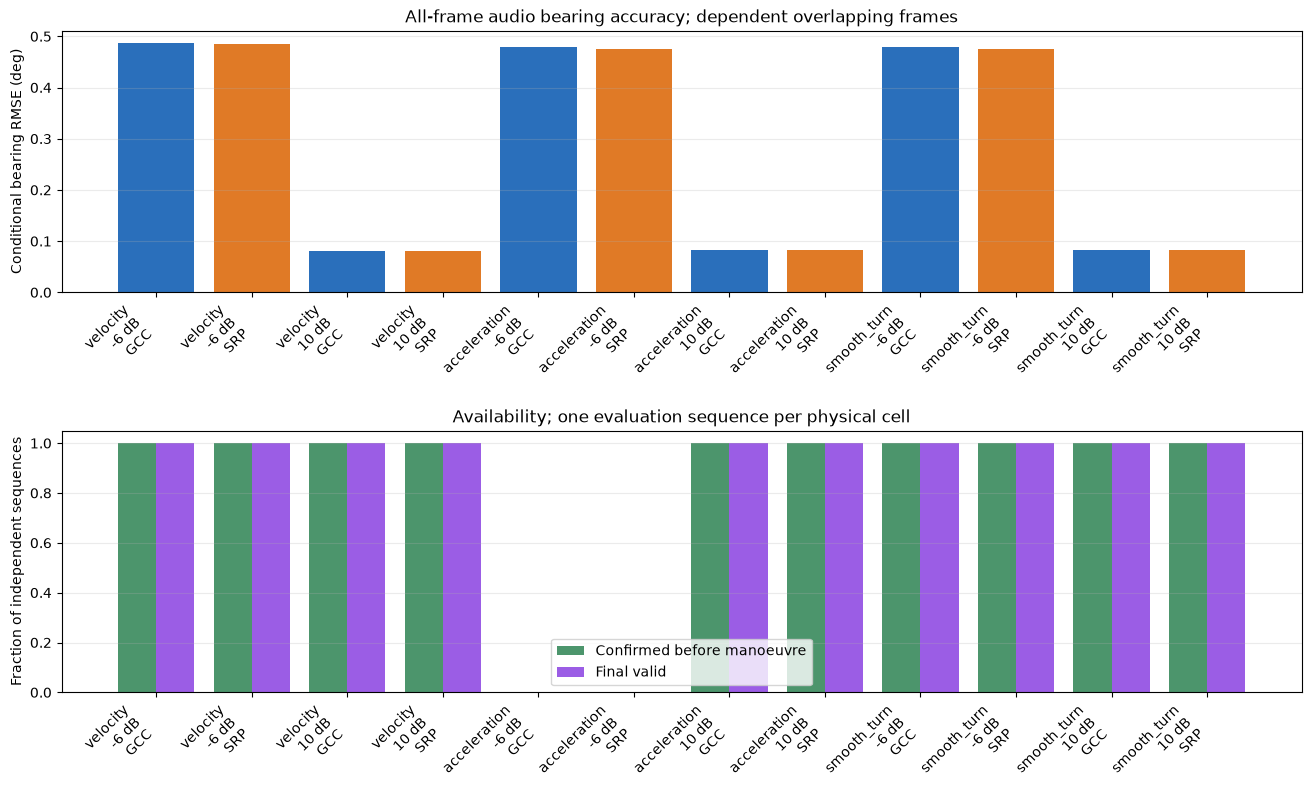

In [4]:
labels = [f"{row['trajectory_kind'].replace('constant_', '').replace('_segment','')}\n{float(row['snr_db']):.0f} dB\n{'GCC' if row['estimator_variant'].startswith('all_6') else 'SRP'}" for row in summary]
bearing_rmse = np.array([float(row['bearing_rmse_deg_conditional']) for row in summary])
confirmed_before = np.array([float(row['confirmed_before_manoeuvre_sequence_fraction']) for row in summary])
final_valid = np.array([float(row['final_valid_sequence_fraction']) for row in summary])
x = np.arange(len(summary))
colors = ['#2a6fbb' if 'gcc' in row['estimator_variant'] else '#e07a26' for row in summary]
fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
axes[0].bar(x, bearing_rmse, color=colors)
axes[0].set_ylabel('Conditional bearing RMSE (deg)')
axes[0].set_title('All-frame audio bearing accuracy; dependent overlapping frames')
axes[0].grid(axis='y', alpha=0.25)
axes[0].set_xticks(x, labels, rotation=45, ha='right')
axes[1].bar(x - 0.2, confirmed_before, width=0.4, label='Confirmed before manoeuvre', color='#4c956c')
axes[1].bar(x + 0.2, final_valid, width=0.4, label='Final valid', color='#9b5de5')
axes[1].set_ylabel('Fraction of independent sequences')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Availability; one evaluation sequence per physical cell')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
axes[1].set_xticks(x, labels, rotation=45, ha='right')
plt.show()

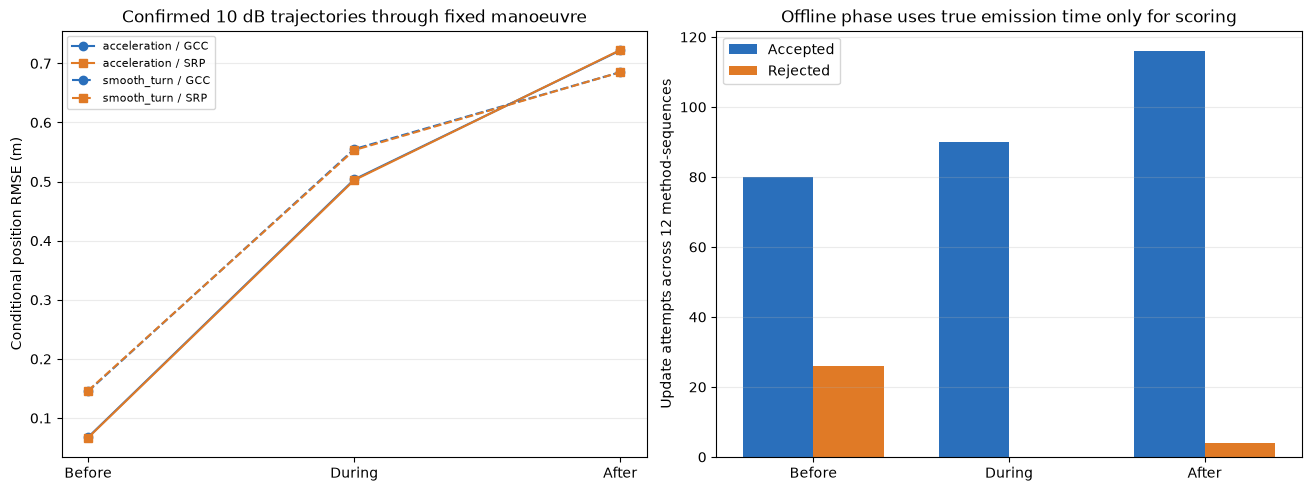

**Zero-correction audit:** `2` streams have no accepted update and remain explicit `prediction_without_correction` failures: constant_acceleration_segment / -6.0 dB / all_6_equal_gcc_wls, constant_acceleration_segment / -6.0 dB / equal_weight_srp_phat

In [5]:
phase_order = ['before_manoeuvre', 'during_manoeuvre', 'after_manoeuvre']
phase_labels = ['Before', 'During', 'After']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for trajectory in ('constant_acceleration_segment', 'smooth_turn'):
    for method, color, marker in (
        ('all_6_equal_gcc_wls', '#2a6fbb', 'o'),
        ('equal_weight_srp_phat', '#e07a26', 's'),
    ):
        selected = [next(row for row in phases if row['trajectory_kind'] == trajectory and row['snr_db'] == '10.0' and row['estimator_variant'] == method and row['motion_phase'] == phase) for phase in phase_order]
        values = [float(row['position_rmse_m_conditional']) for row in selected]
        label = f"{trajectory.replace('constant_', '').replace('_segment','')} / {'GCC' if method.startswith('all_6') else 'SRP'}"
        axes[0].plot(phase_labels, values, marker=marker, color=color, linestyle='-' if trajectory.startswith('constant') else '--', label=label)
axes[0].set_ylabel('Conditional position RMSE (m)')
axes[0].set_title('Confirmed 10 dB trajectories through fixed manoeuvre')
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(fontsize=8)
accepted = [sum(int(row['accepted_update_count']) for row in phases if row['motion_phase'] == phase) for phase in phase_order]
rejected = [sum(int(row['rejected_update_count']) for row in phases if row['motion_phase'] == phase) for phase in phase_order]
px = np.arange(3)
axes[1].bar(px - 0.18, accepted, 0.36, label='Accepted', color='#2a6fbb')
axes[1].bar(px + 0.18, rejected, 0.36, label='Rejected', color='#e07a26')
axes[1].set_xticks(px, phase_labels)
axes[1].set_ylabel('Update attempts across 12 method-sequences')
axes[1].set_title('Offline phase uses true emission time only for scoring')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
plt.show()

failed = [row for row in sequences if row['accepted_update_count'] == '0']
display(Markdown(f"**Zero-correction audit:** `{len(failed)}` streams have no accepted update and remain explicit `prediction_without_correction` failures: " + ', '.join(f"{row['trajectory_kind']} / {row['snr_db']} dB / {row['estimator_variant']}" for row in failed)))

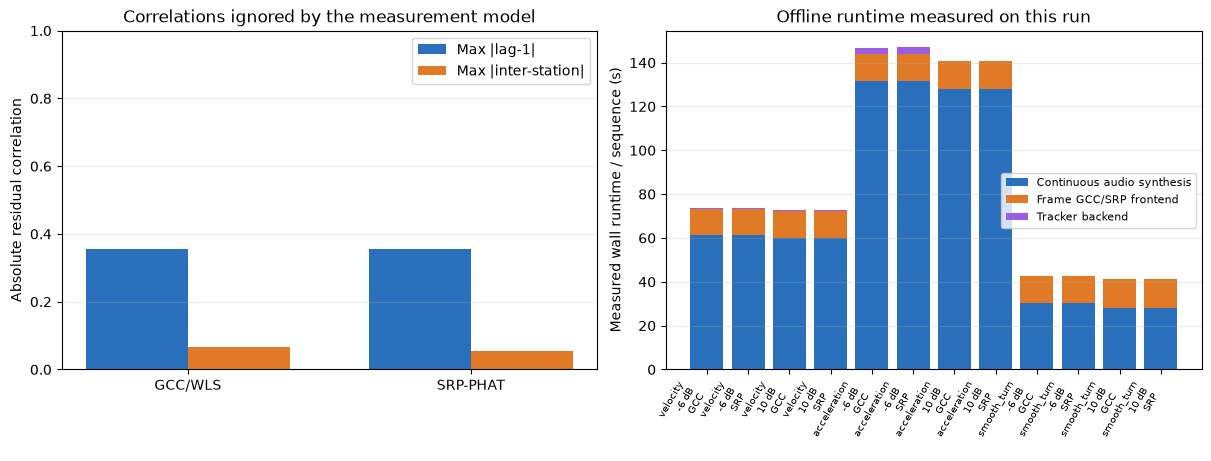

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
methods = ['all_6_equal_gcc_wls', 'equal_weight_srp_phat']
method_labels = ['GCC/WLS', 'SRP-PHAT']
temporal = [max(abs(float(row[k])) for row in calibration if row['estimator_variant'] == method for k in ('temporal_lag1_az', 'temporal_lag1_el')) for method in methods]
interstation = [max(abs(float(row['maximum_absolute_interstation_correlation'])) for row in calibration if row['estimator_variant'] == method) for method in methods]
mx = np.arange(2)
axes[0].bar(mx - 0.18, temporal, 0.36, label='Max |lag-1|', color='#2a6fbb')
axes[0].bar(mx + 0.18, interstation, 0.36, label='Max |inter-station|', color='#e07a26')
axes[0].set_xticks(mx, method_labels)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Absolute residual correlation')
axes[0].set_title('Correlations ignored by the measurement model')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)
synthesis = [float(row['mean_audio_synthesis_wall_runtime_s_per_sequence']) for row in summary]
front = [float(row['mean_bearing_frontend_wall_runtime_s_per_sequence']) for row in summary]
back = [float(row['mean_tracker_runtime_s_per_sequence']) for row in summary]
axes[1].bar(x, synthesis, label='Continuous audio synthesis', color='#2a6fbb')
axes[1].bar(x, front, bottom=synthesis, label='Frame GCC/SRP frontend', color='#e07a26')
axes[1].bar(x, back, bottom=np.asarray(synthesis) + np.asarray(front), label='Tracker backend', color='#9b5de5')
axes[1].set_ylabel('Measured wall runtime / sequence (s)')
axes[1].set_title('Offline runtime measured on this run')
axes[1].set_xticks(x, labels, rotation=60, ha='right', fontsize=7)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.25)
plt.show()

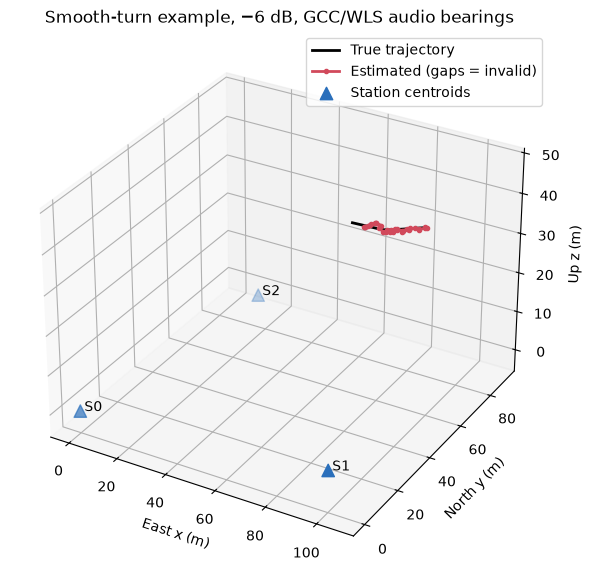

In [7]:
chosen = [row for row in tracking if row['trajectory_kind'] == 'smooth_turn' and row['snr_db'] == '-6.0' and row['estimator_variant'] == 'all_6_equal_gcc_wls']
chosen.sort(key=lambda row: float(row['processing_time_s']))
truth = np.array([[float(row[f'truth_position_{axis}_m']) for axis in 'xyz'] for row in chosen])
estimate = np.array([[float(row[f'estimate_position_{axis}_m']) for axis in 'xyz'] for row in chosen])
valid = np.array([row['valid'] == 'True' for row in chosen])
estimate[~valid] = np.nan
stations_xyz = np.array([[0., 0., 0.], [100., 0., 5.], [10., 90., -2.]])
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(*truth.T, color='black', linewidth=2, label='True trajectory')
ax.plot(*estimate.T, color='#d1495b', linewidth=2, marker='o', markersize=3, label='Estimated (gaps = invalid)')
ax.scatter(*stations_xyz.T, color='#2a6fbb', marker='^', s=80, label='Station centroids')
for index, station in enumerate(stations_xyz):
    ax.text(*station, f' S{index}')
ax.set_xlabel('East x (m)'); ax.set_ylabel('North y (m)'); ax.set_zlabel('Up z (m)')
ax.set_title('Smooth-turn example, −6 dB, GCC/WLS audio bearings')
ax.legend()
plt.show()

## Takeaways and limitations

- Evaluation-time `BearingMeasurement` construction depends only on station, estimator output, timestamps, observable quality, and the pre-fitted `(station, estimator)` calibration. Changing evaluator trajectory/SNR labels leaves it unchanged.
- Ten of twelve method-sequences confirm by 1.5854 s, before the fixed manoeuvre at 2.5 s, and each receives nine accepted bearing updates whose true emission times lie during the manoeuvre. The two acceleration/−6 dB streams never confirm; their phase rows explicitly say prediction without correction rather than reporting fictitious errors.
- Conditional position RMSE for valid streams is about 0.113–0.991 m. Coverage is 0.806–1.0 for the valid aggregate cells, but this tiny pilot does not establish calibration or rare-tail behavior.
- The known 10 kHz source edge passes the explicit Doppler/Nyquist guard. An aliasing configuration is rejected in unit tests.
- Lag-1 residual correlation reaches about 0.355 and inter-station correlation about 0.067. The tracker assumes independent measurement errors, so its posterior covariance remains a diagnostic, not a signal-level CRLB.
- The estimator uses every 32nd frame, and measured wall runtime does not enter simulated availability. The propagation medium remains homogeneous and stationary; reflections, wind, correlated background, source radiation calibration and field validation remain out of scope.